In [1]:
import sys

import importlib
import numpy as np
import os

# Remontée de deux niveaux pour accéder à Data_loader
current_dir = os.getcwd()
project_root = os.path.normpath(os.path.join(current_dir, "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Chemin du projet : {project_root}")

Chemin du projet : /home/loai/Documents/code/RSMLExtraction


In [ ]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Dict
from RSA_deep_working.Data_loader import Dataloaders
import numpy as np
import torch
from tqdm import tqdm

OUTPUT_DIR = Path("/home/loai/Documents/code/RSMLExtraction/RSA_deep_working/TDA/output")

In [3]:
base_directory = "/home/loai/Images/DataTest/UC1_data"
img_transform = None
mask_transform_image = None
mask_transform_series = None

# Create loaders
train_loader, val_loader, test_loader, val_loader_series, test_loader_series = Dataloaders.create_dataloader(
    base_directory,
    img_transform=img_transform,
    mask_transform_image=mask_transform_image,
    mask_transform_series=mask_transform_series,
    num_workers=8)

Nombre de séries : 28
Nombre d'images (toutes séries confondues) : 812

Number of Training series : 19
Number of Validation series : 5
Number of Testing series : 4

Number of Training images : 551
Number of Validation images : 145
Number of Testing images : 116



Image shape: torch.Size([29, 1166, 1348])
Mask shape: torch.Size([29, 1166, 1348])
Times shape: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])
MTG paths: 29


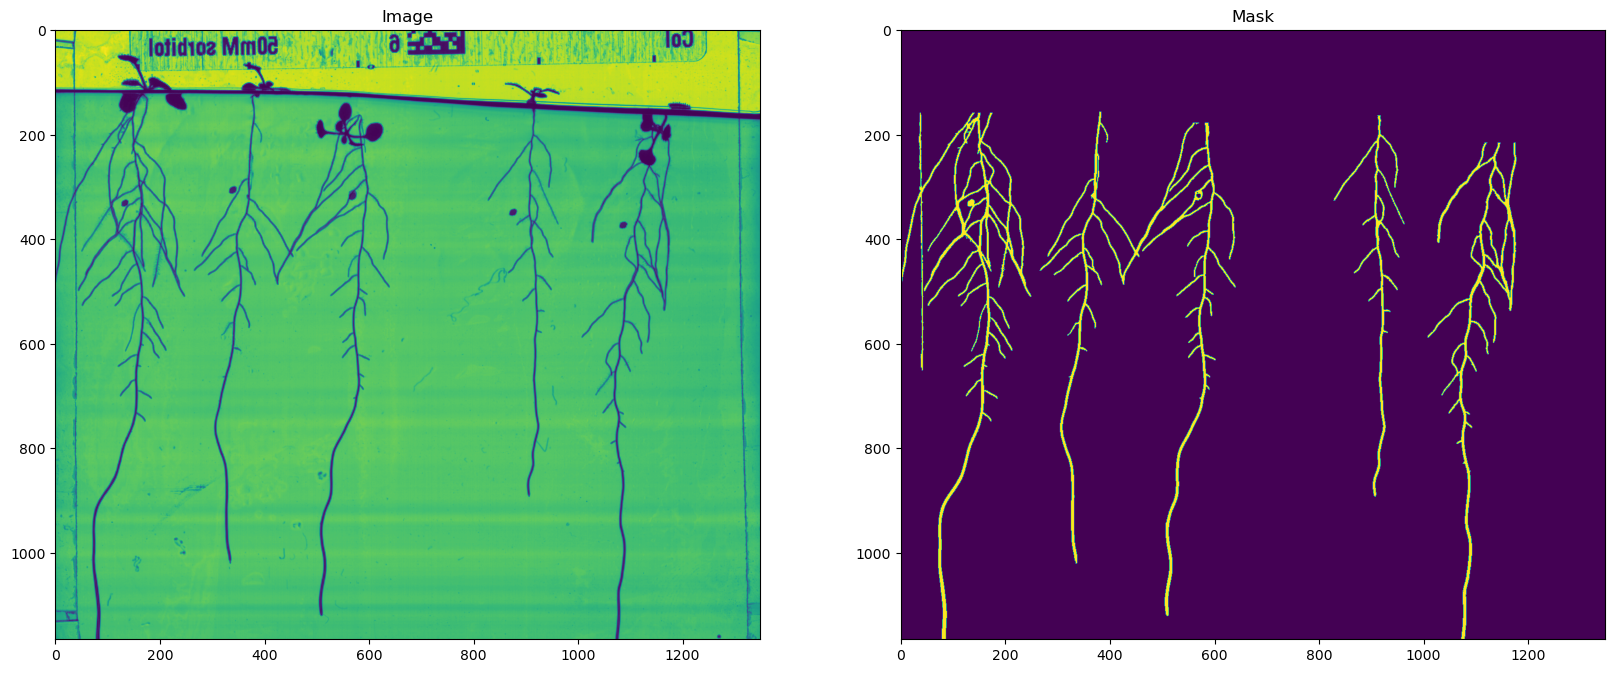

In [4]:
# load and show one image from val_loader
batch = next(iter(val_loader_series))
imgs, masks, times, mtg_paths = batch
print(f"Image shape: {imgs.shape}")
print(f"Mask shape: {masks.shape}")
print(f"Times shape: {times}")
print(f"MTG paths: {len(mtg_paths)}")

# show last image
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(imgs[-1, :, :])
plt.title("Image")
plt.subplot(1, 2, 2)
plt.imshow(masks[-1, :, :])
plt.title("Mask")
plt.show()

## Complexe cubique

In [25]:
# load mask from path
mask_path = "/home/loai/Images/DataTest/UC1_data/230629PN005/40_date_map.tif"
# load mask
import tifffile as tiff

mask = tiff.imread(mask_path)
# convert to numpy array
np_mask = np.array(mask)
np_mask = np_mask.astype(np.uint8)
# binarize the mask
np_mask[np_mask > 0] = 1
# geodesic distance 
from skimage.graph import MCP_Geometric

# 1) On définit un « coût » uniforme à l’intérieur, infini à l’extérieur
cost = np.where(np_mask, 1.0, np.inf)

# 2) On choisit un ou plusieurs points-sources. 
#    Par exemple la frontière du masque :
# Ensure np_mask is of integer type before applying the ~ operator
np_mask_int = np_mask.astype(np.uint8)
# Ou un seul point (i0,j0) à l’intérieur :

seeds = [(200, 200)]

# 3) On crée l’objet MCP_Geometric pour tenir compte des distances euclidiennes
mcp = MCP_Geometric(cost, sampling=(1.0, 50.0))

# 4) On calcule la distance géodésique depuis les seeds
#    distances[i,j] = distance minimale pour atteindre (i,j) depuis l’un des seeds
distances, traceback = mcp.find_costs(starts=seeds)

# distances est un ndarray de même forme que mask, avec inf là où pas de chemin.

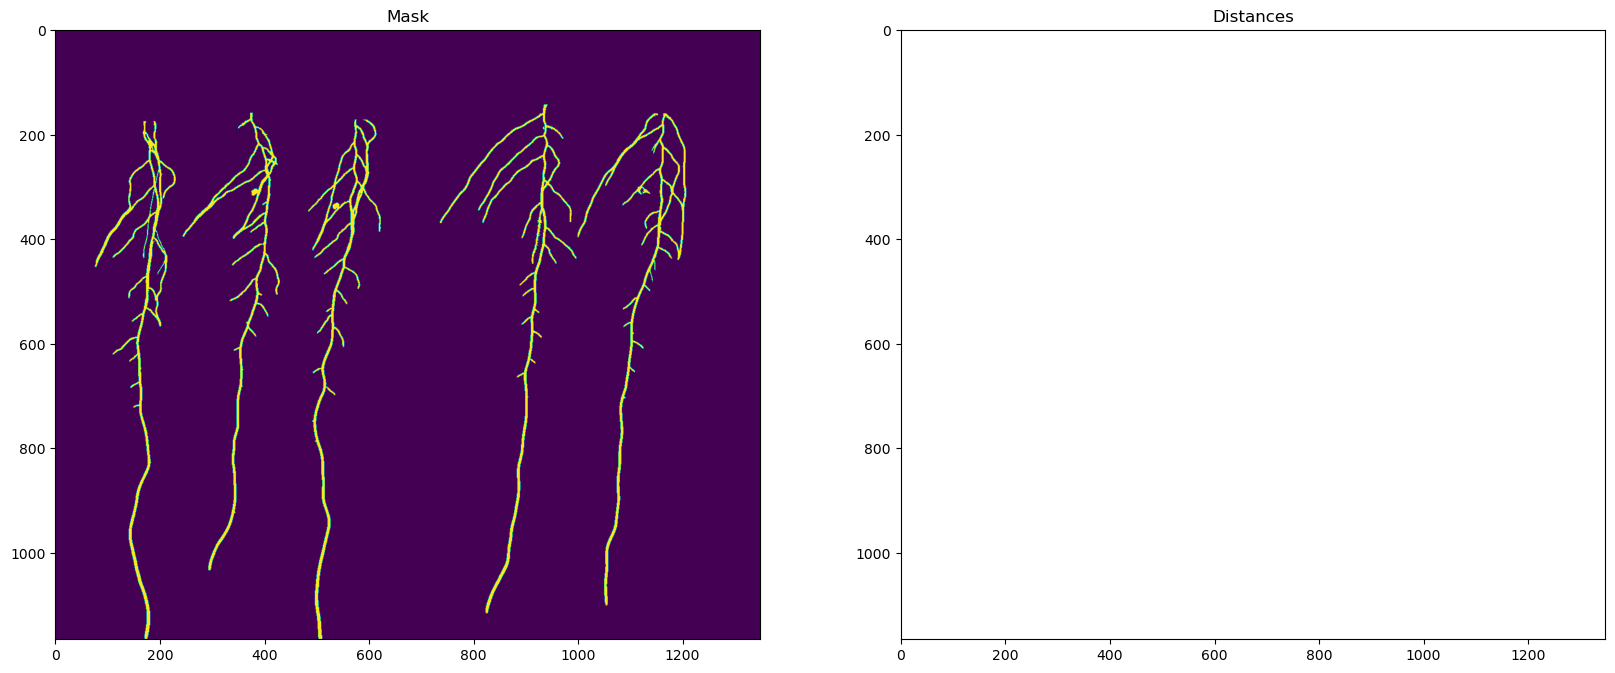

In [26]:
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(np_mask)
plt.title("Mask")
plt.subplot(1, 2, 2)
plt.imshow(distances)
plt.title("Distances")
plt.show()

2
6292101
[(1, (0.0, 29.0)), (1, (0.0, 29.0)), (1, (0.0, 29.0)), (1, (1.0, 29.0)), (1, (1.0, 29.0)), (1, (1.0, 29.0)), (1, (1.0, 29.0)), (1, (1.0, 29.0)), (1, (1.0, 29.0)), (1, (1.0, 29.0)), (1, (1.0, 29.0)), (1, (1.0, 29.0)), (1, (1.0, 29.0)), (1, (1.0, 29.0)), (1, (1.0, 29.0)), (1, (1.0, 29.0)), (1, (2.0, 29.0)), (1, (2.0, 29.0)), (1, (2.0, 29.0)), (1, (2.0, 29.0)), (1, (3.0, 29.0)), (1, (3.0, 29.0)), (1, (1.0, 27.0)), (1, (3.0, 29.0)), (1, (3.0, 29.0)), (1, (4.0, 29.0)), (1, (4.0, 29.0)), (1, (5.0, 29.0)), (1, (5.0, 29.0)), (1, (5.0, 29.0)), (1, (6.0, 29.0)), (1, (6.0, 29.0)), (1, (5.0, 28.0)), (1, (5.0, 28.0)), (1, (6.0, 29.0)), (1, (6.0, 29.0)), (1, (7.0, 29.0)), (1, (3.0, 25.0)), (1, (8.0, 29.0)), (1, (8.0, 29.0)), (1, (7.0, 28.0)), (1, (8.0, 29.0)), (1, (1.0, 22.0)), (1, (8.0, 29.0)), (1, (8.0, 29.0)), (1, (9.0, 29.0)), (1, (9.0, 29.0)), (1, (1.0, 21.0)), (1, (1.0, 21.0)), (1, (9.0, 29.0)), (1, (9.0, 29.0)), (1, (10.0, 29.0)), (1, (5.0, 24.0)), (1, (10.0, 29.0)), (1, (10.0, 29.0

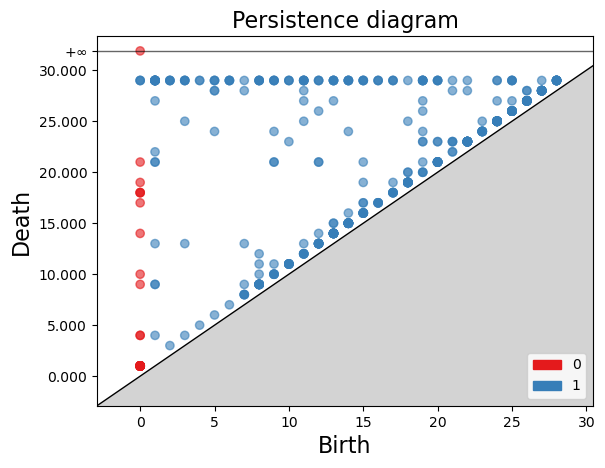

In [ ]:
# convert to uint8
import gudhi as gd

# filter the mask with pixel values 
np_mask = mask.astype(np.uint8)
# create a Gudhi cubical complex
cc = gd.CubicalComplex(top_dimensional_cells=np_mask)
print(cc.dimension())
print(cc.num_simplices())
# compute the persistence diagram
persistence_diagram = cc.persistence()
print(persistence_diagram)
# plot the persistence diagram
gd.plot_persistence_diagram(persistence_diagram)
plt.show()
